# Sequence Classification: Extended Training with Tripeptide Data

This notebook extends the autoencoder training from v4 by including **both dipeptide-AA and tripeptide-dipeptide pairs** in the training data.

## Strategy

**Training Data (Mixed):**
| Pair Type | Input 1 | Input 2 | Target | Examples |
|-----------|---------|---------|--------|----------|
| Dipeptide-AA | Dipeptide XY | Amino acid X | Y | (AF, A) -> F |
| Tripeptide-Dipeptide | Tripeptide XYZ | Dipeptide XY | Z | (AFG, AF) -> G |

**Holdout (Transfer Evaluation):** All tripeptides starting with 'RA' (RAD, RAG, RAS)

**Hypothesis:** Including tripeptide-dipeptide pairs in training should help the model generalize better to unseen tripeptide patterns.

## 1. Imports and Setup

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns

# Import our custom modules
from spectra.models import (
    AutoencoderModelConfig,
    AutoencoderDiffClassifier,
    AutoencoderTrainer,
    TrainingConfig,
    train_autoencoder_model,
)
from spectra.data import SpectraDataset, SequenceDataset

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10

Using device: cuda


## 2. Constants and Data Loading

In [2]:
# Target amino acid classes (will be determined from data)
CODE_TO_NAME = {
    'A': 'Alanine',
    'D': 'Aspartic acid',
    'F': 'Phenylalanine',
    'G': 'Glycine',
    'R': 'Arginine',
    'S': 'Serine'
}

# Holdout prefixes (for transfer evaluation)
HOLDOUT_PREFIXES = ['AG', 'AS', 'DG', 'DR', 'DS', 'FA', 'FD', 'FR', 'FS', 'GA', 'GR', 'SD', 'SR']

print(f'Holdout prefixes: {HOLDOUT_PREFIXES}')

Holdout prefixes: ['AG', 'AS', 'DG', 'DR', 'DS', 'FA', 'FD', 'FR', 'FS', 'GA', 'GR', 'SD', 'SR']


In [3]:
# Load all spectra using SpectraDataset
data_root = Path('../data/processed')

spectra_data = SpectraDataset(data_root, min_spectra=5)

print(f'Loaded spectra:')
print(f'  Amino acids: {len(spectra_data.aminoacids)} ({sorted(spectra_data.aminoacids.keys())})')
print(f'  Dipeptides: {len(spectra_data.dipeptides)} ({sorted(spectra_data.dipeptides.keys())})')
print(f'  Tripeptides: {len(spectra_data.tripeptides)} ({sorted(spectra_data.tripeptides.keys())})')
print(f'  Wavelengths: {spectra_data.wavelengths.shape}')
print(f'  Total spectra: {len(spectra_data)}')

Loaded spectra:
  Amino acids: 20 (['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y'])
  Dipeptides: 29 (['AD', 'AF', 'AG', 'AR', 'AS', 'DA', 'DF', 'DG', 'DR', 'DS', 'FA', 'FD', 'FG', 'FR', 'FS', 'GA', 'GD', 'GF', 'GR', 'RA', 'RD', 'RF', 'RG', 'RS', 'SA', 'SD', 'SF', 'SG', 'SR'])
  Tripeptides: 33 (['AFG', 'AFR', 'AGF', 'ARS', 'ASF', 'DFA', 'DFS', 'DGF', 'DRF', 'DSR', 'FAR', 'FDR', 'FGA', 'FGR', 'FGS', 'FRS', 'FSA', 'FSG', 'FSR', 'GAR', 'GDR', 'GDS', 'GRS', 'RAG', 'RAS', 'RFD', 'RSA', 'RSD', 'RSF', 'SDF', 'SGA', 'SGF', 'SRA'])
  Wavelengths: (1023,)
  Total spectra: 56175


In [4]:
# Summary of spectra per code
print('Amino acid spectra counts:')
for code in sorted(spectra_data.aminoacids.keys()):
    print(f'  {code}: {len(spectra_data.aminoacids[code])} spectra')

print(f'\nDipeptide spectra counts:')
for code in sorted(spectra_data.dipeptides.keys()):
    print(f'  {code}: {len(spectra_data.dipeptides[code])} spectra')

Amino acid spectra counts:
  A: 2414 spectra
  C: 1450 spectra
  D: 1003 spectra
  E: 1464 spectra
  F: 2338 spectra
  G: 2064 spectra
  H: 584 spectra
  I: 263 spectra
  K: 190 spectra
  L: 1790 spectra
  M: 2024 spectra
  N: 1563 spectra
  P: 1445 spectra
  Q: 1586 spectra
  R: 1533 spectra
  S: 2205 spectra
  T: 638 spectra
  V: 1675 spectra
  W: 2139 spectra
  Y: 208 spectra

Dipeptide spectra counts:
  AD: 397 spectra
  AF: 1246 spectra
  AG: 1446 spectra
  AR: 188 spectra
  AS: 31 spectra
  DA: 318 spectra
  DF: 1372 spectra
  DG: 483 spectra
  DR: 586 spectra
  DS: 141 spectra
  FA: 15 spectra
  FD: 226 spectra
  FG: 1432 spectra
  FR: 347 spectra
  FS: 570 spectra
  GA: 58 spectra
  GD: 732 spectra
  GF: 1476 spectra
  GR: 859 spectra
  RA: 209 spectra
  RD: 446 spectra
  RF: 196 spectra
  RG: 439 spectra
  RS: 102 spectra
  SA: 181 spectra
  SD: 14 spectra
  SF: 190 spectra
  SG: 44 spectra
  SR: 205 spectra


In [5]:
# Tripeptide spectra counts and holdout/training split
print('Tripeptide spectra counts:')
training_tripeptides = []
holdout_tripeptides = []

for code in sorted(spectra_data.tripeptides.keys()):
    n_spectra = len(spectra_data.tripeptides[code])
    is_holdout = any(code.startswith(prefix) for prefix in HOLDOUT_PREFIXES)
    if is_holdout:
        holdout_tripeptides.append(code)
        marker = ' (holdout)'
    else:
        training_tripeptides.append(code)
        marker = ''
    print(f'  {code}: {n_spectra} spectra{marker}')

print(f'\nTraining tripeptides ({len(training_tripeptides)}): {training_tripeptides}')
print(f'Holdout tripeptides ({len(holdout_tripeptides)}): {holdout_tripeptides}')

Tripeptide spectra counts:
  AFG: 229 spectra
  AFR: 57 spectra
  AGF: 520 spectra (holdout)
  ARS: 29 spectra
  ASF: 707 spectra (holdout)
  DFA: 264 spectra
  DFS: 1301 spectra
  DGF: 80 spectra (holdout)
  DRF: 147 spectra (holdout)
  DSR: 276 spectra (holdout)
  FAR: 401 spectra (holdout)
  FDR: 250 spectra (holdout)
  FGA: 293 spectra
  FGR: 161 spectra
  FGS: 838 spectra
  FRS: 652 spectra (holdout)
  FSA: 660 spectra (holdout)
  FSG: 35 spectra (holdout)
  FSR: 340 spectra (holdout)
  GAR: 189 spectra (holdout)
  GDR: 1847 spectra
  GDS: 1519 spectra
  GRS: 139 spectra (holdout)
  RAG: 267 spectra
  RAS: 179 spectra
  RFD: 211 spectra
  RSA: 9 spectra
  RSD: 89 spectra
  RSF: 82 spectra
  SDF: 103 spectra (holdout)
  SGA: 34 spectra
  SGF: 272 spectra
  SRA: 1470 spectra (holdout)

Training tripeptides (18): ['AFG', 'AFR', 'ARS', 'DFA', 'DFS', 'FGA', 'FGR', 'FGS', 'GDR', 'GDS', 'RAG', 'RAS', 'RFD', 'RSA', 'RSD', 'RSF', 'SGA', 'SGF']
Holdout tripeptides (15): ['AGF', 'ASF', 'DGF'

### 3. Create Datasets

In [9]:
# Create combined training dataset using SequenceDataset
print('Creating combined training dataset...')
print('  - Dipeptide-AA pairs: (XY, X) -> Y')
print('  - Tripeptide-Dipeptide pairs: (XYZ, XY) -> Z (excluding holdout prefixes)')

combined_dataset = SequenceDataset(
    spectra_dataset=spectra_data,
    include_dipeptide_pairs=True,
    include_tripeptide_pairs=True,
    exclude_prefixes=HOLDOUT_PREFIXES,
    samples_per_pair=100,
    seed=42,
)

# Get class info
AMINO_ACID_CODES = combined_dataset.get_label_names()
CODE_TO_IDX = combined_dataset.code_to_idx
IDX_TO_CODE = {idx: code for code, idx in CODE_TO_IDX.items()}

print(f'\nTotal combined samples: {len(combined_dataset)}')
print(f'Number of classes: {combined_dataset.num_classes}')
print(f'Target classes: {AMINO_ACID_CODES}')

print('\nClass distribution:')
class_dist = combined_dataset.get_class_distribution()
for code, count in sorted(class_dist.items()):
    name = CODE_TO_NAME.get(code, code)
    print(f'  {code} ({name}): {count} samples')

Creating combined training dataset...
  - Dipeptide-AA pairs: (XY, X) -> Y
  - Tripeptide-Dipeptide pairs: (XYZ, XY) -> Z (excluding holdout prefixes)

Total combined samples: 4700
Number of classes: 6
Target classes: ['A', 'D', 'F', 'G', 'R', 'S']

Class distribution:
  A (Alanine): 900 samples
  D (Aspartic acid): 700 samples
  F (Phenylalanine): 700 samples
  G (Glycine): 700 samples
  R (Arginine): 800 samples
  S (Serine): 900 samples


In [10]:
# Create dipeptide-only dataset (for comparison with v4)
print('Creating dipeptide-only dataset (for baseline comparison)...')

dipeptide_only_dataset = SequenceDataset(
    spectra_dataset=spectra_data,
    include_dipeptide_pairs=True,
    include_tripeptide_pairs=False,
    samples_per_pair=100,
    seed=42,
)

print(f'Total dipeptide-only samples: {len(dipeptide_only_dataset)}')
print(f'Class distribution: {dipeptide_only_dataset.get_class_distribution()}')

Creating dipeptide-only dataset (for baseline comparison)...
Total dipeptide-only samples: 2900
Class distribution: {'A': 500, 'D': 500, 'F': 500, 'G': 500, 'R': 500, 'S': 400}


In [11]:
# Create holdout tripeptide dataset for transfer evaluation
print('Creating holdout tripeptide dataset for transfer evaluation...')

holdout_dataset = SequenceDataset(
    spectra_dataset=spectra_data,
    include_dipeptide_pairs=False,
    include_tripeptide_pairs=True,
    include_prefixes=HOLDOUT_PREFIXES,  # Only include holdout tripeptides
    samples_per_pair=100,
    seed=42,
)

print(f'Total holdout samples: {len(holdout_dataset)}')
print('\nHoldout class distribution:')
holdout_dist = holdout_dataset.get_class_distribution()
for code, count in sorted(holdout_dist.items()):
    print(f'  {code}: {count} samples')

Creating holdout tripeptide dataset for transfer evaluation...
Total holdout samples: 1500

Holdout class distribution:
  A: 200 samples
  D: 0 samples
  F: 500 samples
  G: 100 samples
  R: 500 samples
  S: 200 samples


In [12]:
# Create ALL tripeptides dataset (for full transfer comparison)
print('Creating all tripeptides dataset (for full transfer comparison)...')

all_tripeptides_dataset = SequenceDataset(
    spectra_dataset=spectra_data,
    include_dipeptide_pairs=False,
    include_tripeptide_pairs=True,
    samples_per_pair=100,
    seed=42,
)

print(f'Total all tripeptides samples: {len(all_tripeptides_dataset)}')
print(f'Class distribution: {all_tripeptides_dataset.get_class_distribution()}')

Creating all tripeptides dataset (for full transfer comparison)...
Total all tripeptides samples: 3300
Class distribution: {'A': 600, 'D': 200, 'F': 700, 'G': 300, 'R': 800, 'S': 700}


## 5. Train/Validation Split

In [13]:
# Stratified train/val split for combined dataset
labels = [sample[2] for sample in combined_dataset.samples]  # Extract labels from samples
indices = list(range(len(combined_dataset)))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_subset = Subset(combined_dataset, train_indices)
val_subset = Subset(combined_dataset, val_indices)

print(f'Training samples: {len(train_subset)}')
print(f'Validation samples: {len(val_subset)}')

Training samples: 3760
Validation samples: 940


## 6. Helper Functions

In [14]:
def collate_fn(batch):
    """Custom collate function for paired data."""
    s_xy = torch.stack([b[0] for b in batch])
    s_x = torch.stack([b[1] for b in batch])
    labels = torch.stack([b[2] for b in batch])
    return s_xy, s_x, labels


def evaluate_model(model, data_loader, device):
    """Evaluate model and return accuracy and predictions."""
    model.eval()
    all_predictions = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for s_xy, s_x, labels in data_loader:
            s_xy, s_x = s_xy.to(device), s_x.to(device)
            
            if hasattr(model, 'predict'):
                outputs = model.predict(s_xy, s_x)
            else:
                outputs = model(s_xy, s_x)
            
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    accuracy = 100.0 * np.mean(np.array(all_predictions) == np.array(all_labels))
    return accuracy, np.array(all_predictions), np.array(all_labels), np.array(all_probs)

## 7. Model Training

In [15]:
# Create data loaders
batch_size = 32

# Holdout RA* loader
holdout_loader = DataLoader(
    holdout_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=collate_fn
)

# All tripeptides loader (for comparison)
all_tripeptides_loader = DataLoader(
    all_tripeptides_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn
)

# Dipeptide-only loader (for comparison)
dipeptide_only_loader = DataLoader(
    dipeptide_only_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn
)

# Training configuration
training_config = TrainingConfig(
    learning_rate=0.0001,
    weight_decay=1e-4,
    epochs=50,
    batch_size=batch_size,
    early_stopping_patience=100,
    device=device,
)

print(f'Training config: lr={training_config.learning_rate}, epochs={training_config.epochs}')

Training config: lr=0.0001, epochs=50


In [16]:
# Model configuration (latent_dim=64 - best from v4)
ae_config = AutoencoderModelConfig(
    seq_length=1023,
    encoder_dims=(512, 256),
    latent_dim=64,  # Best from v4
    dropout=0.3,
    num_classes=6,
    activation='relu',
    reconstruction_weight=10.0,
    classification_weight=1.0,
)

print('Model Configuration:')
print(f'  Latent dimension: {ae_config.latent_dim}')
print(f'  Encoder dims: {ae_config.encoder_dims}')
print(f'  Dropout: {ae_config.dropout}')
print(f'  Reconstruction weight: {ae_config.reconstruction_weight}')
print(f'  Classification weight: {ae_config.classification_weight}')

Model Configuration:
  Latent dimension: 64
  Encoder dims: (512, 256)
  Dropout: 0.3
  Reconstruction weight: 10.0
  Classification weight: 1.0


In [17]:
# Create and train model
print('='*70)
print('Training: Autoencoder (latent_dim=64, combined dipeptide+tripeptide)')
print('='*70)

model = AutoencoderDiffClassifier(ae_config)
print(f'Parameters: {model.count_parameters():,}')

# Train with joint loss
model, history = train_autoencoder_model(
    model=model,
    train_dataset=train_subset,
    val_dataset=val_subset,
    config=training_config,
    reconstruction_weight=100.0,
    classification_weight=1.0,
    pretrain_epochs=0,
    verbose=True,
)

Training: Autoencoder (latent_dim=64, combined dipeptide+tripeptide)
Parameters: 1,352,709
Training AutoencoderDiffClassifier on cuda
Train samples: 3760
Val samples: 940
Model parameters: 1,352,709
Loss weights: recon=100.0, class=1.0
----------------------------------------------------------------------
Epoch   1/50 | Loss: 32.4288 (R:0.3019 C:2.2425) | Val: 5.5747 (R:0.0418 C:1.3969) | Acc: 23.7%/57.6% | LR: 1.00e-04
Epoch   2/50 | Loss: 11.6298 (R:0.0982 C:1.8138) | Val: 2.2836 (R:0.0095 C:1.3308) | Acc: 39.0%/71.6% | LR: 1.00e-04
Epoch   3/50 | Loss: 6.2772 (R:0.0477 C:1.5061) | Val: 1.8482 (R:0.0081 C:1.0405) | Acc: 55.4%/84.3% | LR: 1.00e-04
Epoch   4/50 | Loss: 4.9147 (R:0.0368 C:1.2386) | Val: 1.6401 (R:0.0074 C:0.9021) | Acc: 67.5%/85.3% | LR: 1.00e-04
Epoch   5/50 | Loss: 4.1835 (R:0.0310 C:1.0839) | Val: 1.6751 (R:0.0084 C:0.8353) | Acc: 74.0%/89.1% | LR: 1.00e-04
Epoch   6/50 | Loss: 3.5745 (R:0.0259 C:0.9802) | Val: 1.3951 (R:0.0065 C:0.7456) | Acc: 78.3%/89.8% | LR: 1.00

## 8. Evaluation

In [18]:
# Create validation loader
val_loader = DataLoader(
    val_subset, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=collate_fn
)

# Evaluate on all datasets
print('\nEvaluating model on different datasets...')

# Validation set (mixed)
val_acc, val_preds, val_labels, val_probs = evaluate_model(model, val_loader, device)
print(f'\n1. Validation Accuracy (mixed dipeptide+tripeptide): {val_acc:.2f}%')

# Dipeptide-only evaluation
dip_acc, dip_preds, dip_labels, dip_probs = evaluate_model(model, dipeptide_only_loader, device)
print(f'2. Dipeptide-only Accuracy: {dip_acc:.2f}%')

# All tripeptides (including training tripeptides)
all_tri_acc, all_tri_preds, all_tri_labels, all_tri_probs = evaluate_model(model, all_tripeptides_loader, device)
print(f'3. All Tripeptides Accuracy: {all_tri_acc:.2f}%')

# Holdout RA* tripeptides (transfer evaluation)
holdout_acc, holdout_preds, holdout_labels, holdout_probs = evaluate_model(model, holdout_loader, device)
print(f'4. Holdout RA* Transfer Accuracy: {holdout_acc:.2f}%')


Evaluating model on different datasets...

1. Validation Accuracy (mixed dipeptide+tripeptide): 99.04%
2. Dipeptide-only Accuracy: 99.83%
3. All Tripeptides Accuracy: 88.06%
4. Holdout RA* Transfer Accuracy: 76.00%


In [19]:
# Results summary
print('' + '='*70)
print('RESULTS SUMMARY: Extended Training with Tripeptide Data')
print('='*70)

print('Model: Autoencoder with latent_dim=64, joint training')
print('Training: Combined dipeptide-AA + tripeptide-dipeptide pairs (excluding RA*)')

print('Performance:')
print(f'  Validation Accuracy (mixed):     {val_acc:.2f}%')
print(f'  Dipeptide-only Accuracy:         {dip_acc:.2f}%')
print(f'  All Tripeptides Accuracy:        {all_tri_acc:.2f}%')
print(f'  Holdout RA* Transfer Accuracy:   {holdout_acc:.2f}%')

print('Generalization Gaps:')
print(f'  Dipeptide -> All Tripeptide:      {dip_acc - all_tri_acc:.2f}%')
print(f'  Validation -> Holdout RA*:        {val_acc - holdout_acc:.2f}%')

print('Comparison with v4 (dipeptide-only training):')
print('  v4 Validation Accuracy:          ~99.14%')
print('  v4 Tripeptide Transfer:          ~63.78%')
print('  v4 Generalization Gap:           ~35.36%')

RESULTS SUMMARY: Extended Training with Tripeptide Data
Model: Autoencoder with latent_dim=64, joint training
Training: Combined dipeptide-AA + tripeptide-dipeptide pairs (excluding RA*)
Performance:
  Validation Accuracy (mixed):     99.04%
  Dipeptide-only Accuracy:         99.83%
  All Tripeptides Accuracy:        88.06%
  Holdout RA* Transfer Accuracy:   76.00%
Generalization Gaps:
  Dipeptide -> All Tripeptide:      11.77%
  Validation -> Holdout RA*:        23.04%
Comparison with v4 (dipeptide-only training):
  v4 Validation Accuracy:          ~99.14%
  v4 Tripeptide Transfer:          ~63.78%
  v4 Generalization Gap:           ~35.36%


## 9. Confusion Matrices

C:\Users\mfarzi\AppData\Local\Temp\ipykernel_23828\3215082632.py:23: RuntimeWarning: invalid value encountered in divide
  cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100


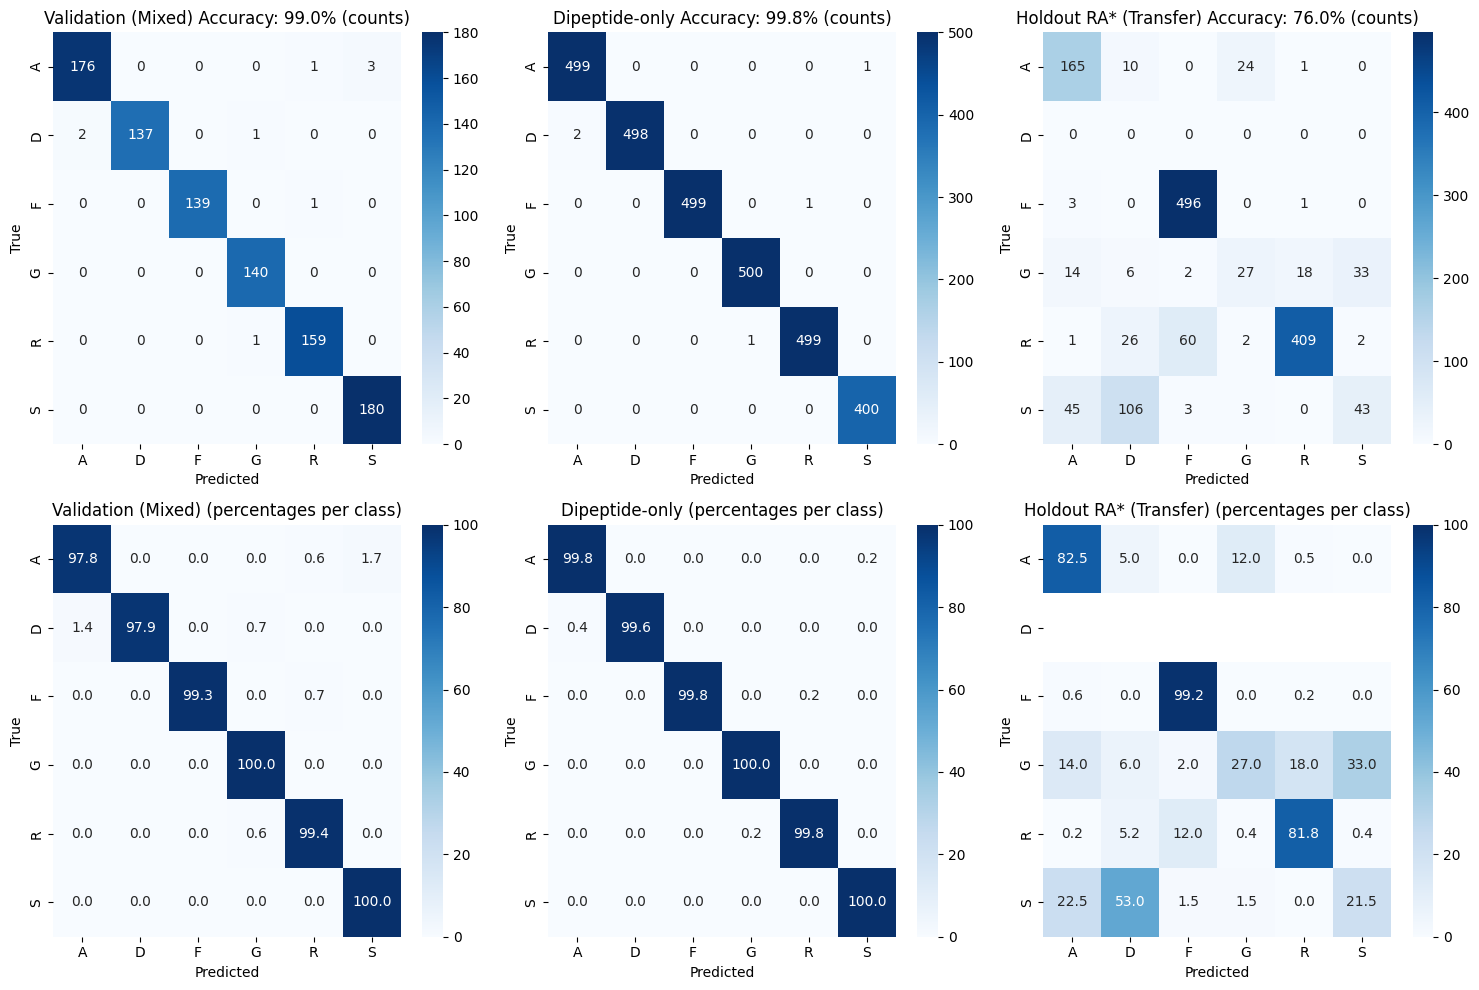

In [20]:
# Plot confusion matrices (absolute numbers and percentages)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

datasets_to_plot = [
    ('Validation (Mixed)', val_labels, val_preds, val_acc),
    ('Dipeptide-only', dip_labels, dip_preds, dip_acc),
    ('Holdout RA* (Transfer)', holdout_labels, holdout_preds, holdout_acc),
]

# Top row: Absolute numbers
for ax, (title, labels, preds, acc) in zip(axes[0], datasets_to_plot):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=AMINO_ACID_CODES, yticklabels=AMINO_ACID_CODES)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{title} Accuracy: {acc:.1f}% (counts)')

# Bottom row: Percentages (normalized by true label)
for ax, (title, labels, preds, acc) in zip(axes[1], datasets_to_plot):
    cm = confusion_matrix(labels, preds)
    # Normalize by row (true labels) to get percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', ax=ax,
                xticklabels=AMINO_ACID_CODES, yticklabels=AMINO_ACID_CODES,
                vmin=0, vmax=100)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{title} (percentages per class)')

plt.tight_layout()
plt.savefig('confusion_matrices_v5.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Per-class Analysis for Holdout

In [21]:
# Detailed analysis of holdout performance
print('\nDetailed Holdout Analysis:')
print('-'*50)

# Get per-tripeptide accuracy
tripeptide_results = {}
model.eval()

with torch.no_grad():
    for i, (s_xy, s_x, label) in enumerate(holdout_dataset):
        s_xy = s_xy.unsqueeze(0).to(device)
        s_x = s_x.unsqueeze(0).to(device)
        
        output = model.predict(s_xy, s_x)
        pred = output.argmax(dim=1).item()
        
        # Get tripeptide name from sample_codes
        tripeptide_name = holdout_dataset.sample_codes[i]
        if tripeptide_name not in tripeptide_results:
            tripeptide_results[tripeptide_name] = {'correct': 0, 'total': 0, 'target': label.item()}
        
        tripeptide_results[tripeptide_name]['total'] += 1
        if pred == label.item():
            tripeptide_results[tripeptide_name]['correct'] += 1

print(f'{"Tripeptide":<12} {"Target":<8} {"Accuracy":<12} {"Correct/Total"}')
print('-'*50)

for tripeptide, results in sorted(tripeptide_results.items()):
    acc = 100.0 * results['correct'] / results['total']
    target_code = IDX_TO_CODE[results['target']]
    print(f'{tripeptide:<12} {target_code:<8} {acc:>6.1f}%      {results["correct"]}/{results["total"]}')


Detailed Holdout Analysis:
--------------------------------------------------
Tripeptide   Target   Accuracy     Correct/Total
--------------------------------------------------
AGF          F          99.0%      99/100
ASF          F         100.0%      100/100
DGF          F         100.0%      100/100
DRF          F          99.0%      99/100
DSR          R          96.0%      96/100
FAR          R          39.0%      39/100
FDR          R         100.0%      100/100
FRS          S          14.0%      14/100
FSA          A          69.0%      69/100
FSG          G          27.0%      27/100
FSR          R          75.0%      75/100
GAR          R          99.0%      99/100
GRS          S          29.0%      29/100
SDF          F          98.0%      98/100
SRA          A          96.0%      96/100


## 11. Latent Space Visualization

In [22]:
# Extract latent representations for visualization (including amino acids)
def extract_raw_latent(model, spectra_dict, device, max_samples_per_class=100):
    """Extract raw latent vectors for single-level spectra (amino acids, dipeptides, tripeptides)."""
    model.eval()
    latent_vectors = []
    names = []

    with torch.no_grad():
        for name, spectra in spectra_dict.items():
            n_samples = min(len(spectra), max_samples_per_class)
            indices = np.random.choice(len(spectra), n_samples, replace=False)

            for idx in indices:
                spectrum = torch.tensor(spectra[idx], dtype=torch.float32).unsqueeze(0).to(device)
                z = model.encode(spectrum)
                latent_vectors.append(z.cpu().numpy().squeeze())
                names.append(name)

    return np.array(latent_vectors), names

# Extract latent representations for each level
print('Extracting latent representations for all peptide levels...')

# Amino acids (single)
aa_latent, aa_names = extract_raw_latent(model, spectra_data.aminoacids, device, max_samples_per_class=150)
print(f'Amino acids: {aa_latent.shape}')

# Dipeptides
dip_latent, dip_names = extract_raw_latent(model, spectra_data.dipeptides, device, max_samples_per_class=30)
print(f'Dipeptides: {dip_latent.shape}')

# Tripeptides (training) - filter out holdout prefixes
training_tripeptide_dict = {k: v for k, v in spectra_data.tripeptides.items() 
                            if not any(k.startswith(p) for p in HOLDOUT_PREFIXES)}
tri_latent, tri_names = extract_raw_latent(model, training_tripeptide_dict, device, max_samples_per_class=30)
print(f'Tripeptides (training): {tri_latent.shape}')

# Holdout tripeptides
holdout_tripeptide_dict = {k: v for k, v in spectra_data.tripeptides.items() 
                           if any(k.startswith(p) for p in HOLDOUT_PREFIXES)}
holdout_tri_latent, holdout_tri_names = extract_raw_latent(model, holdout_tripeptide_dict, device, max_samples_per_class=50)
print(f'Tripeptides (holdout): {holdout_tri_latent.shape}')

Extracting latent representations for all peptide levels...
Amino acids: (3000, 64)
Dipeptides: (839, 64)
Tripeptides (training): (518, 64)
Tripeptides (holdout): (735, 64)


In [23]:
# Combine all latent vectors for joint t-SNE embedding
print('Computing t-SNE for all peptide levels...')

# Combine
all_latent = np.vstack([aa_latent, dip_latent, tri_latent, holdout_tri_latent])
all_names = aa_names + dip_names + tri_names + holdout_tri_names

# Create labels for peptide level
peptide_levels = (['Amino Acid'] * len(aa_latent) +
                  ['Dipeptide'] * len(dip_latent) +
                  ['Tripeptide (Train)'] * len(tri_latent) +
                  ['Tripeptide (Holdout RA*)'] * len(holdout_tri_latent))

# Create amino acid class labels (last character of name for peptides, full name for AAs)
aa_classes = []
for name in all_names:
    if len(name) == 1:  # Single amino acid
        aa_classes.append(name)
    else:  # Dipeptide or tripeptide - use last character
        aa_classes.append(name[-1])

print(f'Total samples: {len(all_latent)}')
for level in ['Amino Acid', 'Dipeptide', 'Tripeptide (Train)', 'Tripeptide (Holdout RA*)']:
    count = sum(1 for l in peptide_levels if l == level)
    print(f'  {level}: {count}')

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=50)
latent_2d = tsne.fit_transform(all_latent)
print('t-SNE complete!')

Computing t-SNE for all peptide levels...
Total samples: 5092
  Amino Acid: 3000
  Dipeptide: 839
  Tripeptide (Train): 518
  Tripeptide (Holdout RA*): 735
t-SNE complete!


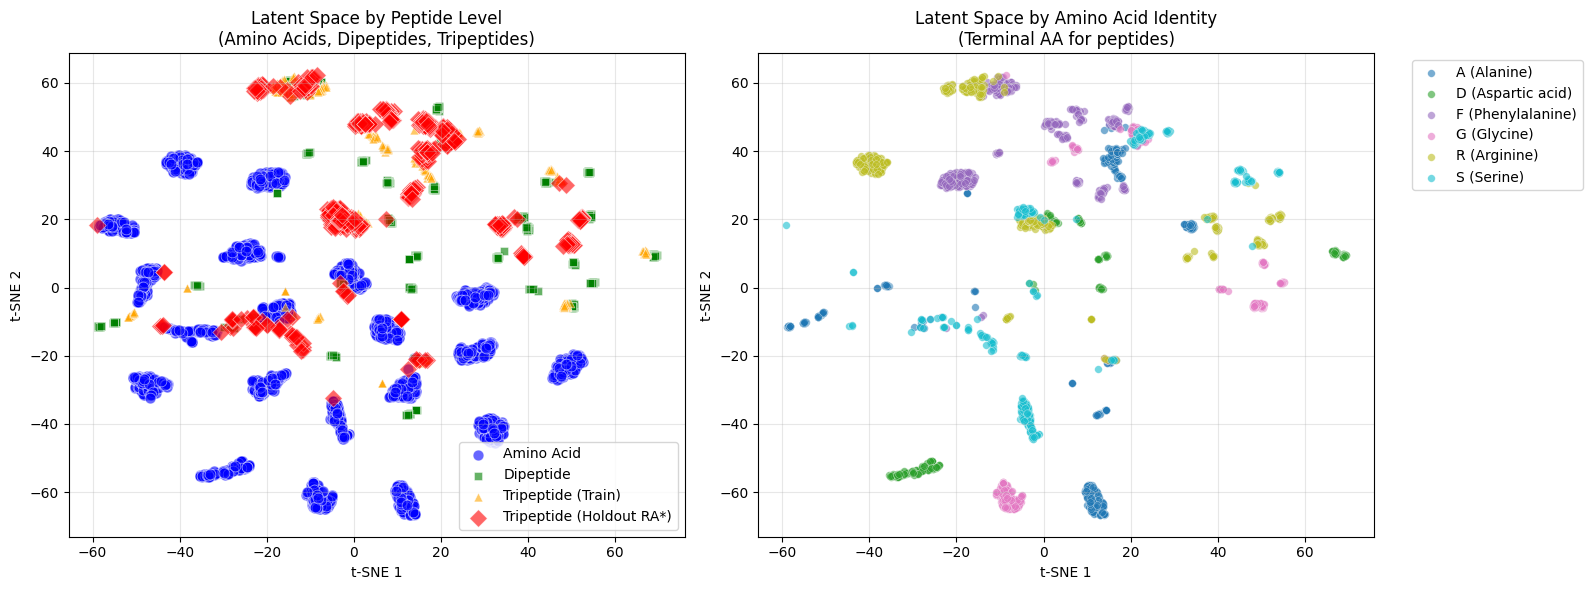


Samples per level:
  Amino Acid: 3000
  Dipeptide: 839
  Tripeptide (Train): 518
  Tripeptide (Holdout RA*): 735


In [24]:
# Plot t-SNE with peptide levels and amino acid classes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: By Peptide Level
ax = axes[0]
level_colors = {
    'Amino Acid': 'blue',
    'Dipeptide': 'green',
    'Tripeptide (Train)': 'orange',
    'Tripeptide (Holdout RA*)': 'red'
}
level_markers = {
    'Amino Acid': 'o',
    'Dipeptide': 's',
    'Tripeptide (Train)': '^',
    'Tripeptide (Holdout RA*)': 'D'
}
level_sizes = {
    'Amino Acid': 60,
    'Dipeptide': 40,
    'Tripeptide (Train)': 40,
    'Tripeptide (Holdout RA*)': 80
}

for level in ['Amino Acid', 'Dipeptide', 'Tripeptide (Train)', 'Tripeptide (Holdout RA*)']:
    mask = np.array(peptide_levels) == level
    ax.scatter(latent_2d[mask, 0], latent_2d[mask, 1],
               c=level_colors[level], marker=level_markers[level],
               s=level_sizes[level], label=level, alpha=0.6, edgecolors='white', linewidth=0.5)

ax.legend(loc='best')
ax.set_title('Latent Space by Peptide Level\n(Amino Acids, Dipeptides, Tripeptides)', fontsize=12)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.grid(True, alpha=0.3)

# Plot 2: By Amino Acid Class (colored by the terminal amino acid)
ax = axes[1]
colors = plt.cm.tab10(np.linspace(0, 1, len(AMINO_ACID_CODES)))
color_map = {code: colors[i] for i, code in enumerate(AMINO_ACID_CODES)}

for code in AMINO_ACID_CODES:
    mask = np.array(aa_classes) == code
    if mask.sum() > 0:
        ax.scatter(latent_2d[mask, 0], latent_2d[mask, 1],
                   c=[color_map[code]], label=f'{code} ({CODE_TO_NAME[code]})',
                   alpha=0.6, s=30, edgecolors='white', linewidth=0.3)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_title('Latent Space by Amino Acid Identity\n(Terminal AA for peptides)', fontsize=12)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('latent_space_v5_all_levels.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSamples per level:')
for level in ['Amino Acid', 'Dipeptide', 'Tripeptide (Train)', 'Tripeptide (Holdout RA*)']:
    count = sum(1 for l in peptide_levels if l == level)
    print(f'  {level}: {count}')

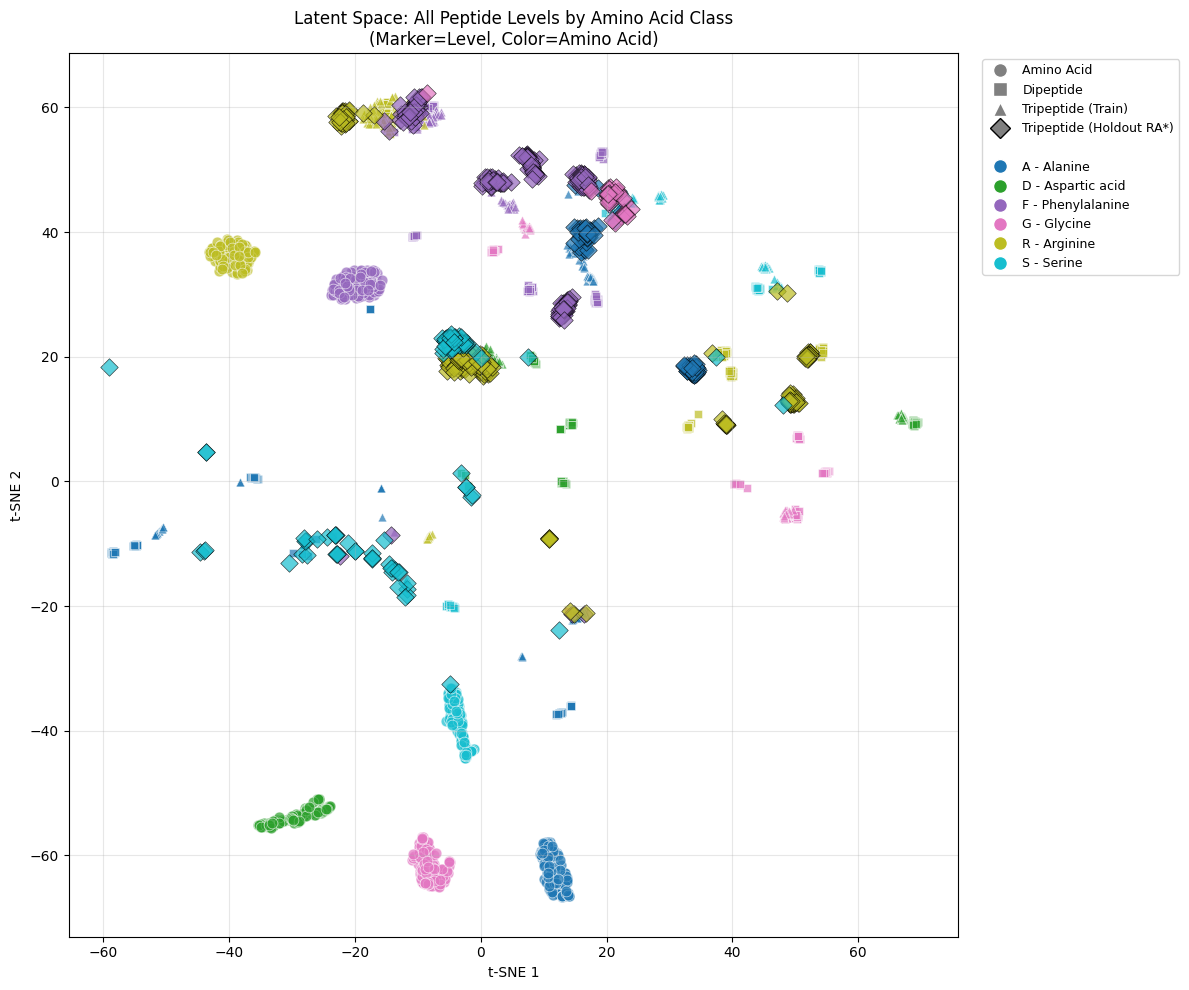

In [25]:
# Detailed visualization: markers by level, colors by amino acid
from matplotlib.lines import Line2D

# Define visualization settings
level_markers = {
    'Amino Acid': 'o',
    'Dipeptide': 's',
    'Tripeptide (Train)': '^',
    'Tripeptide (Holdout RA*)': 'D'
}
level_sizes = {
    'Amino Acid': 60,
    'Dipeptide': 40,
    'Tripeptide (Train)': 40,
    'Tripeptide (Holdout RA*)': 80
}
colors = plt.cm.tab10(np.linspace(0, 1, len(AMINO_ACID_CODES)))
color_map = {code: colors[i] for i, code in enumerate(AMINO_ACID_CODES)}

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot each combination of level and amino acid class
for level in ['Amino Acid', 'Dipeptide', 'Tripeptide (Train)', 'Tripeptide (Holdout RA*)']:
    level_mask = np.array(peptide_levels) == level

    for code in AMINO_ACID_CODES:
        aa_mask = np.array(aa_classes) == code
        combined_mask = level_mask & aa_mask

        if combined_mask.sum() > 0:
            ax.scatter(latent_2d[combined_mask, 0], latent_2d[combined_mask, 1],
                       c=[color_map[code]], marker=level_markers[level],
                       s=level_sizes[level], alpha=0.7,
                       edgecolors='black' if level == 'Tripeptide (Holdout RA*)' else 'white',
                       linewidth=0.5)

# Create custom legend
legend_elements = []

# Level markers (shapes)
legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                              markersize=10, label='Amino Acid'))
legend_elements.append(Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
                              markersize=10, label='Dipeptide'))
legend_elements.append(Line2D([0], [0], marker='^', color='w', markerfacecolor='gray',
                              markersize=10, label='Tripeptide (Train)'))
legend_elements.append(Line2D([0], [0], marker='D', color='w', markerfacecolor='gray',
                              markersize=10, markeredgecolor='black', label='Tripeptide (Holdout RA*)'))
legend_elements.append(Line2D([0], [0], color='w', label=''))  # Spacer

# Amino acid colors
for code in AMINO_ACID_CODES:
    legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[code],
                                  markersize=10, label=f'{code} - {CODE_TO_NAME[code]}'))

ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
ax.set_title('Latent Space: All Peptide Levels by Amino Acid Class' + chr(10) + '(Marker=Level, Color=Amino Acid)', fontsize=12)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('latent_space_v5_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

Checking available peptides...
  Available amino acids: ['G', 'A', 'R', 'N', 'D', 'C', 'E', 'Q', 'H', 'I', 'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']
  Available dipeptides: ['AD', 'AF', 'AG', 'AR', 'AS', 'DA', 'DF', 'DG', 'DR', 'DS', 'FA', 'FD', 'FG', 'FR', 'FS', 'GA', 'GD', 'GF', 'GR', 'RA', 'RD', 'RF', 'RG', 'RS', 'SA', 'SD', 'SF', 'SG', 'SR']
  Available tripeptides: ['AFG', 'AFR', 'AGF', 'ARS', 'ASF', 'DFA', 'DFS', 'DGF', 'DRF', 'DSR', 'FAR', 'FDR', 'FGA', 'FGR', 'FGS', 'FRS', 'FSA', 'FSG', 'FSR', 'GAR', 'GDR', 'GDS', 'GRS', 'RAG', 'RAS', 'RFD', 'RSA', 'RSD', 'RSF', 'SDF', 'SGA', 'SGF', 'SRA']
Extracting latent vectors...
  A: 100 samples (amino acid)
  R: 100 samples (amino acid)
  S: 100 samples (amino acid)
  AR: 100 samples (dipeptide)
  RA: 100 samples (dipeptide)
  RAS: 100 samples (tripeptide)
  ARS: 29 samples (tripeptide)
Total samples: 629
Computing t-SNE...


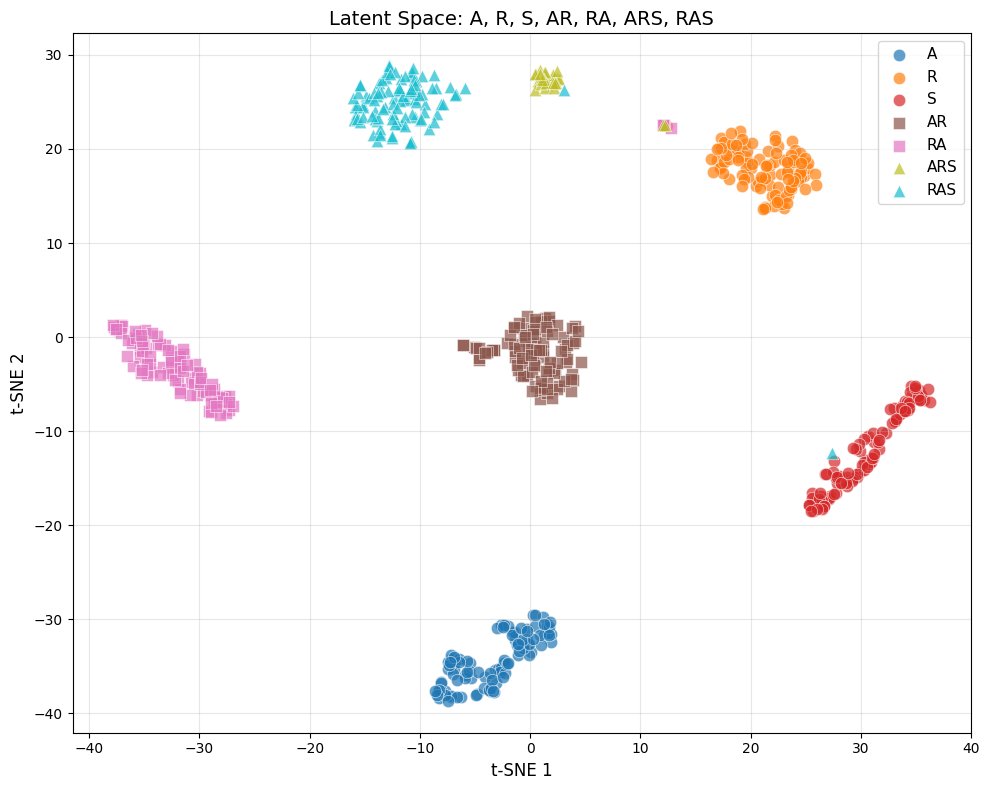


Samples per peptide:
  A: 100
  R: 100
  S: 100
  AR: 100
  RA: 100
  ARS: 29
  RAS: 100


In [26]:
# Visualize specific peptides in t-SNE (supports amino acids, dipeptides, and tripeptides)
# Change these to the peptides you want to visualize
specific_peptides = ['A', 'R', 'S', 'AR', 'RA', 'RAS', 'ARS']  # Example: modify this list

print('Checking available peptides...')
print(f'  Available amino acids: {list(spectra_data.aminoacids.keys())}')
print(f'  Available dipeptides: {sorted(spectra_data.dipeptides.keys())}')
print(f'  Available tripeptides: {sorted(spectra_data.tripeptides.keys())}')

print('Extracting latent vectors...')
specific_latent = []
specific_names = []

with torch.no_grad():
    for name in specific_peptides:
        spectra = spectra_data.get_spectra(name)
        if spectra is not None:
            n_samples = min(100, len(spectra))
            indices = np.random.choice(len(spectra), n_samples, replace=n_samples > len(spectra))
            for idx in indices:
                spectrum = torch.tensor(spectra[idx], dtype=torch.float32).unsqueeze(0).to(device)
                z = model.encode(spectrum)
                specific_latent.append(z.cpu().numpy().squeeze())
                specific_names.append(name)
            ptype = 'amino acid' if len(name) == 1 else ('dipeptide' if len(name) == 2 else 'tripeptide')
            print(f'  {name}: {n_samples} samples ({ptype})')
        else:
            print(f'  {name}: NOT FOUND')

if len(specific_latent) == 0:
    print('No data found for the specified peptides!')
else:
    specific_latent = np.array(specific_latent)
    print(f'Total samples: {len(specific_latent)}')

    # t-SNE
    print('Computing t-SNE...')
    perplexity = min(30, len(specific_latent) - 1)
    tsne_specific = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    specific_2d = tsne_specific.fit_transform(specific_latent)

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    # Auto-generate colors and markers for found peptides
    found_peptides = sorted(set(specific_names), key=lambda x: (len(x), x))  # Sort by length, then name
    colors_list = plt.cm.tab10(np.linspace(0, 1, len(found_peptides)))
    # Markers: circles for AA, squares for dipeptides, triangles for tripeptides
    def get_marker(name):
        if len(name) == 1:
            return 'o'
        elif len(name) == 2:
            return 's'
        else:
            return '^'

    for i, peptide in enumerate(found_peptides):
        mask = np.array(specific_names) == peptide
        marker = get_marker(peptide)
        ax.scatter(specific_2d[mask, 0], specific_2d[mask, 1],
                   c=[colors_list[i]], marker=marker,
                   s=80, label=peptide, alpha=0.7,
                   edgecolors='white', linewidth=0.5)

    ax.legend(loc='best', fontsize=11)
    title = 'Latent Space: ' + ', '.join(found_peptides)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('t-SNE 1', fontsize=12)
    ax.set_ylabel('t-SNE 2', fontsize=12)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('latent_space_custom.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('')
    print('Samples per peptide:')
    for peptide in found_peptides:
        count = sum(1 for n in specific_names if n == peptide)
        print(f'  {peptide}: {count}')

## 12. Training History

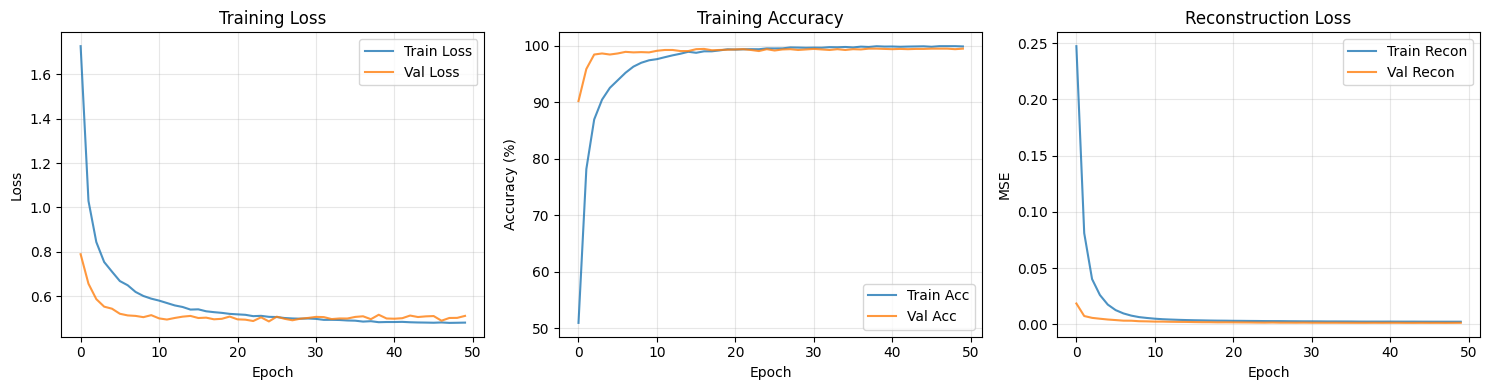

In [35]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
ax = axes[0]
ax.plot(history['train_loss'], label='Train Loss', alpha=0.8)
ax.plot(history['val_loss'], label='Val Loss', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(history['train_acc'], label='Train Acc', alpha=0.8)
ax.plot(history['val_acc'], label='Val Acc', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Training Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# Reconstruction loss (if available)
ax = axes[2]
if 'train_recon_loss' in history:
    ax.plot(history['train_recon_loss'], label='Train Recon', alpha=0.8)
    ax.plot(history['val_recon_loss'], label='Val Recon', alpha=0.8)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.set_title('Reconstruction Loss')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'Reconstruction loss\nnot available', 
            ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Reconstruction Loss')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_v5.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Final Summary

In [ ]:
print('='*80)
print('FINAL SUMMARY: Extended Training with Tripeptide Data (v5)')
print('='*80)

print('\n** Model Configuration **')
print(f'  Architecture: AutoencoderDiffClassifier')
print(f'  Latent dimension: {ae_config.latent_dim}')
print(f'  Encoder dims: {ae_config.encoder_dims}')
print(f'  Parameters: {model.count_parameters():,}')

print('\n** Training Data **')
print(f'  Total samples: {len(combined_dataset)}')
print(f'  Classes: {combined_dataset.num_classes} ({", ".join(AMINO_ACID_CODES)})')
print(f'  Holdout prefixes: {HOLDOUT_PREFIXES}')
print(f'  Holdout samples: {len(holdout_dataset)}')

print('\n** Results **')
print(f'  Validation Accuracy (mixed):     {val_acc:.2f}%')
print(f'  Dipeptide-only Accuracy:         {dip_acc:.2f}%')
print(f'  All Tripeptides Accuracy:        {all_tri_acc:.2f}%')
print(f'  Holdout Transfer Accuracy:       {holdout_acc:.2f}%')

print('\n** Comparison with v4 Baseline **')
print('  v4 (dipeptide-only training):')
print('    - Validation: ~99.14%')
print('    - Tripeptide Transfer: ~63.78%')
print('    - Generalization Gap: ~35.36%')
print('  v5 (combined training):')
print(f'    - Validation: {val_acc:.2f}%')
print(f'    - Holdout Transfer: {holdout_acc:.2f}%')
print(f'    - Generalization Gap: {val_acc - holdout_acc:.2f}%')

improvement = holdout_acc - 63.78  # Approximate v4 transfer accuracy
print(f'\n** Transfer Learning Improvement: {improvement:+.2f}% **')

print('\n' + '='*80)